# Naive Bayes Project Exercise

**GOAL: Create a Classification Model that can predict whether or not a person has presence of heart disease based on physical features of that person (age,sex, cholesterol, etc...)**

**Complete the TASKs written in bold below.**

## Imports

**TASK: Run the cell below to import the necessary libraries.**

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Data

This database contains 14 physical attributes based on physical testing of a patient. Blood samples are taken and the patient also conducts a brief exercise test. The "goal" field refers to the presence of heart disease in the patient. It is integer (0 for no presence, 1 for presence). In general, to confirm 100% if a patient has heart disease can be quite an invasive process, so if we can create a model that accurately predicts the likelihood of heart disease, we can help avoid expensive and invasive procedures.

Content

Attribute Information:

* age
* sex
* chest pain type (4 values)
* resting blood pressure
* serum cholestoral in mg/dl
* fasting blood sugar > 120 mg/dl
* resting electrocardiographic results (values 0,1,2)
* maximum heart rate achieved
* exercise induced angina
* oldpeak = ST depression induced by exercise relative to rest
* the slope of the peak exercise ST segment
* number of major vessels (0-3) colored by flourosopy
* thal: 3 = normal; 6 = fixed defect; 7 = reversable defect
* target:0 for no presence of heart disease, 1 for presence of heart disease

Original Source: https://archive.ics.uci.edu/ml/datasets/Heart+Disease


**TASK: Run the cell below to read in the data.**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

%matplotlib inline

In [2]:
df = pd.read_csv(r'C:\Users\ganna\Downloads\GUC_2350_68_67065_2026-04-17T20_14_39\Lab 6\heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
print(df.shape)
print(df.dtypes)
df.describe()

(303, 14)
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [4]:
# Check for missing values
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

# Machine Learning

## Train | Test Split and Scaling

**TASK: Separate the features from the labels into 2 objects, X and y.**

In [5]:
X = df.drop('target', axis=1)
y = df['target']

print('Features shape:', X.shape)
print('Labels shape: ', y.shape)
print('\nClass distribution:\n', y.value_counts())

Features shape: (303, 13)
Labels shape:  (303,)

Class distribution:
 target
1    165
0    138
Name: count, dtype: int64


**TASK: Perform a train test split on the data, with the test size of 10% and a random_state of 101.**

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.10,
    random_state=101
)

print('Training samples :', len(X_train))
print('Test samples     :', len(X_test))

Training samples : 272
Test samples     : 31


**TASK: Create a StandardScaler object and normalize the X train and test set feature data. Make sure you only fit to the training data to avoid data leakage.**

In [7]:
scaler = StandardScaler()

# Fit on train, transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Scaling complete.')
print('Train mean (should be ~0):', X_train_scaled.mean(axis=0).round(3))

Scaling complete.
Train mean (should be ~0): [-0. -0. -0.  0.  0.  0. -0.  0.  0. -0. -0.  0. -0.]


## Naive Bayes Model

**TASK: Create Naive Bayes model

In [8]:
gnb = GaussianNB()
gnb.fit(X_train_scaled, y_train)

print('Model trained successfully.')
print('Classes:', gnb.classes_)

Model trained successfully.
Classes: [0 1]


## Model Performance Evaluation

**TASK: Let's now evaluate your model on the remaining 10% of the data, the test set.**

**TASK: Create the following evaluations:**
* Confusion Matrix Array
* Confusion Matrix Plot
* Classification Report

In [ ]:
#Evaluate the Model on the Test Set
y_pred = gnb.predict(X_test_scaled)

print('Predictions:', y_pred)
print('Actual     :', y_test.values)

Predictions: [0 1 1 1 0 1 1 0 0 1 0 1 0 0 1 1 1 1 1 0 0 0 0 1 1 1 0 1 0 0 0]
Actual     : [0 1 1 1 0 1 1 0 0 1 0 1 0 1 1 1 1 1 1 0 0 0 0 0 0 1 0 1 0 1 0]


In [ ]:
#Confusion Matrix 
cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:\n', cm)
print('\nTN={}, FP={}, FN={}, TP={}'.format(cm[0,0], cm[0,1], cm[1,0], cm[1,1]))

Confusion Matrix:
 [[13  2]
 [ 2 14]]

TN=13, FP=2, FN=2, TP=14


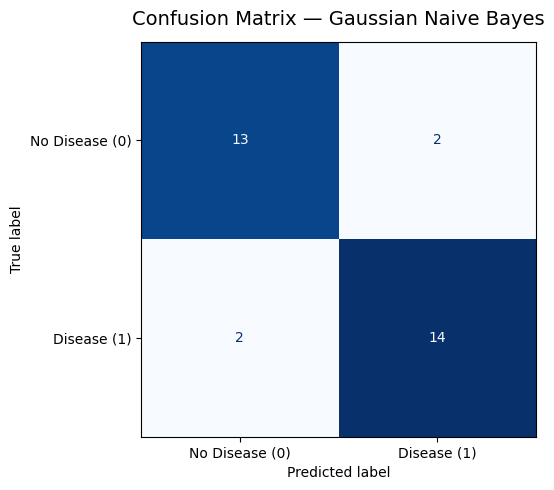

In [11]:
fig, ax = plt.subplots(figsize=(6, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Disease (0)', 'Disease (1)']
)
disp.plot(cmap='Blues', ax=ax, colorbar=False)

ax.set_title('Confusion Matrix — Gaussian Naive Bayes', fontsize=14, pad=12)
plt.tight_layout()
plt.show()

In [ ]:
#classification report
report = classification_report(
    y_test, y_pred,
    target_names=['No Disease (0)', 'Disease (1)']
)
print('Classification Report\n')
print(report)

Classification Report

                precision    recall  f1-score   support

No Disease (0)       0.87      0.87      0.87        15
   Disease (1)       0.88      0.88      0.88        16

      accuracy                           0.87        31
     macro avg       0.87      0.87      0.87        31
  weighted avg       0.87      0.87      0.87        31



**Final Task: A patient with the following features has come into the medical office:**

    age          48.0
    sex           0.0
    cp            2.0
    trestbps    130.0
    chol        275.0
    fbs           0.0
    restecg       1.0
    thalach     139.0
    exang         0.0
    oldpeak       0.2
    slope         2.0
    ca            0.0
    thal          2.0

**TASK: What does your model predict for this patient? Do they have heart disease? How "sure" is your model of this prediction?**

*For convience, we created an array of the features for the patient above*

In [ ]:

patient_features = np.array([[48.0, 0.0, 2.0, 130.0, 275.0,
                               0.0, 1.0, 139.0, 0.0, 0.2,
                               2.0, 0.0, 2.0]])

# Scale using the SAME scaler fitted on training data
patient_scaled = scaler.transform(patient_features)

# Prediction
prediction   = gnb.predict(patient_scaled)[0]
probabilities = gnb.predict_proba(patient_scaled)[0]

print('=== New Patient Prediction ===')
print(f'Predicted class      : {prediction} ({"Heart Disease PRESENT" if prediction == 1 else "No Heart Disease"})')
print(f'Probability class 0  : {probabilities[0]*100:.2f}%  (No Disease)')
print(f'Probability class 1  : {probabilities[1]*100:.2f}%  (Disease)')
print(f'\nModel confidence     : {max(probabilities)*100:.2f}%')

=== New Patient Prediction ===
Predicted class      : 1 (Heart Disease PRESENT)
Probability class 0  : 0.11%  (No Disease)
Probability class 1  : 99.89%  (Disease)

Model confidence     : 99.89%


c:\Users\ganna\anaaconda\lib\site-packages\sklearn\base.py:420: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
